### K-Means Clustering

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_pca = np.load("../data/processed/X_pca.npy")

print("PCA data shape:", X_pca.shape)

PCA data shape: (100778, 23)


In [4]:
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

inertias = []
silhouette_scores = []

# Sample for silhouette calculation
rng = np.random.RandomState(42)
sample_size = 10000

sample_indices = rng.choice(
    X_pca.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X_pca[sample_indices]

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    inertias.append(kmeans.inertia_)

    sample_labels = labels[sample_indices]

    silhouette_scores.append(
        silhouette_score(X_sample, sample_labels)
    )

print("K values:", k_values)
print("Inertias:", inertias)
print("Silhouette scores:", silhouette_scores)

K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Inertias: [2939447.3006767286, 2444825.300553744, 2155388.9683933062, 2014764.625136606, 1876488.1079901662, 1693369.7365503581, 1573060.6918895058, 1471849.2782829518, 1381896.0361767928]
Silhouette scores: [0.3992279473712876, 0.4835742239592328, 0.48637636944644547, 0.5069478394351044, 0.4655649627904435, 0.48525363144836886, 0.5126647578168572, 0.5130196415741488, 0.5234909534008396]


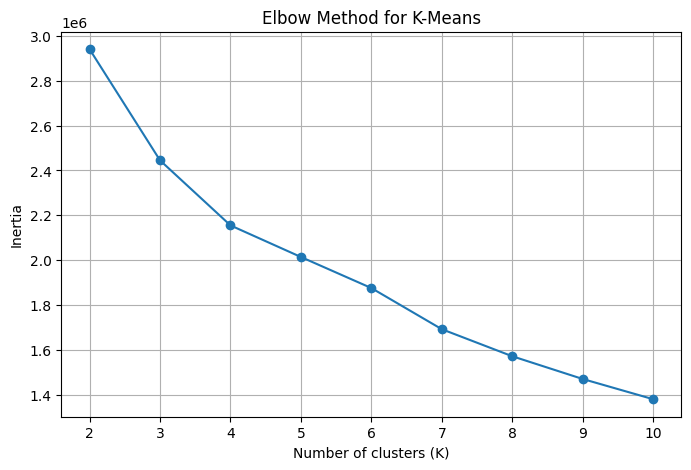

In [5]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(k_values)
plt.grid(True)

plt.show()

In [6]:
additional_k = [12, 15, 20]

for k in additional_k:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    inertia = kmeans.inertia_

    sample_labels = labels[sample_indices]

    silhouette = silhouette_score(
        X_sample,
        sample_labels
    )

    print(
        f"K={k} | "
        f"Inertia={inertia:.2f} | "
        f"Silhouette={silhouette:.4f}"
    )
    

K=12 | Inertia=1203000.18 | Silhouette=0.5396
K=15 | Inertia=965332.40 | Silhouette=0.5346
K=20 | Inertia=687282.94 | Silhouette=0.5610


In [7]:
final_kmeans = KMeans(
    n_clusters=20,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(X_pca)

print("K-Means clustering completed.")
print("Number of clusters:", len(np.unique(cluster_labels)))

K-Means clustering completed.
Number of clusters: 20


In [8]:
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()

print(cluster_counts)
print("\nCluster proportions:")
print((cluster_counts / len(cluster_labels)).round(4))

0      2344
1      6974
2     27796
3     10416
4      9011
5        35
6      3652
7      2137
8     30497
9       709
10      934
11        4
12        1
13       46
14       95
15       19
16        5
17     1788
18     4280
19       35
Name: count, dtype: int64

Cluster proportions:
0     0.0233
1     0.0692
2     0.2758
3     0.1034
4     0.0894
5     0.0003
6     0.0362
7     0.0212
8     0.3026
9     0.0070
10    0.0093
11    0.0000
12    0.0000
13    0.0005
14    0.0009
15    0.0002
16    0.0000
17    0.0177
18    0.0425
19    0.0003
Name: count, dtype: float64


In [9]:
cluster_summary = pd.DataFrame({
    "cluster": cluster_counts.index,
    "count": cluster_counts.values,
    "percentage": (cluster_counts.values / len(cluster_labels) * 100)
})

cluster_summary

,cluster,count,percentage
0,0,2344,2.325904
1,1,6974,6.920161
2,2,27796,27.581417
3,3,10416,10.335589
4,4,9011,8.941436
5,5,35,0.034730
6,6,3652,3.623807
7,7,2137,2.120502
8,8,30497,30.261565
9,9,709,0.703527


In [10]:
y_multiclass_train = np.load(
    "../data/processed/y_multiclass_train.npy",
    allow_pickle=True
)

print("Labels shape:", y_multiclass_train.shape)

Labels shape: (100778,)


In [11]:
cluster_category = pd.crosstab(
    cluster_labels,
    y_multiclass_train
)

cluster_category

col_0,DoS,Normal,Probe,R2L,U2R
row_0,,,,,
0,0,1437,858,49,0
1,276,6618,80,0,0
2,27430,36,328,2,0
3,324,8232,1418,426,16
4,5561,2188,1262,0,0
5,0,35,0,0,0
6,79,299,3247,22,5
7,0,9,2128,0,0
8,683,29796,1,2,15


In [12]:
cluster_purity = cluster_category.max(axis=1) / cluster_category.sum(axis=1)

cluster_summary = pd.DataFrame({
    "cluster": cluster_category.index,
    "size": cluster_category.sum(axis=1),
    "dominant_category": cluster_category.idxmax(axis=1),
    "purity": cluster_purity
})

cluster_summary["purity"] = cluster_summary["purity"].round(4)

cluster_summary

,cluster,size,dominant_category,purity
row_0,,,,
0,0,2344,Normal,0.6131
1,1,6974,Normal,0.9490
2,2,27796,DoS,0.9868
3,3,10416,Normal,0.7903
4,4,9011,DoS,0.6171
5,5,35,Normal,1.0000
6,6,3652,Probe,0.8891
7,7,2137,Probe,0.9958
8,8,30497,Normal,0.9770


In [13]:
cluster_summary.sort_values(
    "purity",
    ascending=False
)

,cluster,size,dominant_category,purity
row_0,,,,
9,9,709,DoS,1.0000
12,12,1,Normal,1.0000
5,5,35,Normal,1.0000
7,7,2137,Probe,0.9958
2,2,27796,DoS,0.9868
18,18,4280,Normal,0.9827
8,8,30497,Normal,0.9770
13,13,46,Normal,0.9565
1,1,6974,Normal,0.9490


In [14]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(
    y_multiclass_train,
    cluster_labels
)

nmi = normalized_mutual_info_score(
    y_multiclass_train,
    cluster_labels
)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI): 0.4243
Normalized Mutual Information (NMI): 0.4737


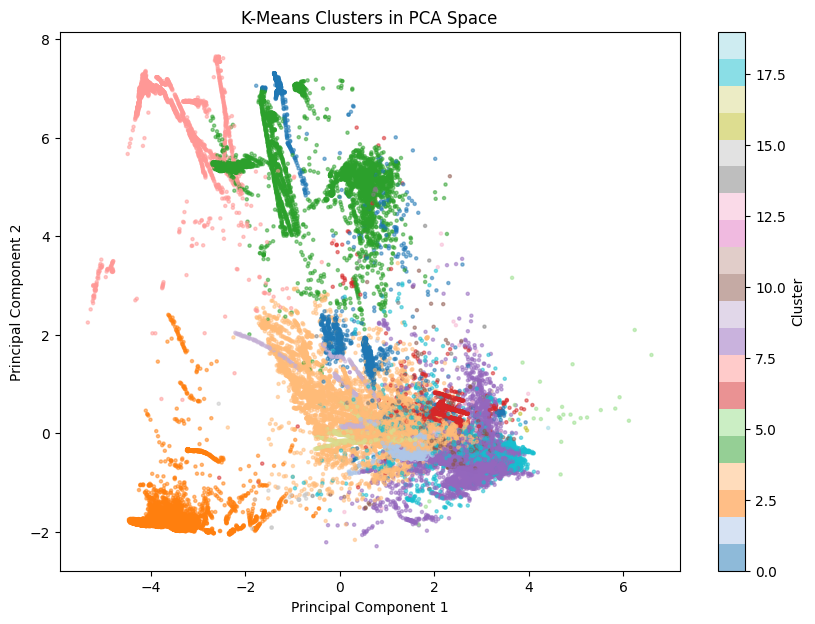

In [15]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_labels,
    cmap="tab20",
    s=5,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in PCA Space")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.show()

In [16]:
import joblib

joblib.dump(
    final_kmeans,
    "../models/kmeans_final.joblib"
)

np.save(
    "../data/processed/kmeans_cluster_labels.npy",
    cluster_labels
)

print("K-Means model and cluster labels saved.")

K-Means model and cluster labels saved.


In [17]:
cluster_summary.to_csv(
    "../results/kmeans_cluster_summary.csv",
    index=False
)

print("Cluster summary saved.")

Cluster summary saved.
